In [1]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr
import src.routines as ro

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

In [2]:
def prepare_transition_set_ofret(number_fluorophores, distance):
    fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=distance, count=number_fluorophores, shape="square"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

    transitions = fluorophore_system.load_transitions(
    summarize=False,
    irradiance=5,
    wavelength=640,
    bleaching=True,
    energy_transfer=True,
    dstorm=True,
    dstorm_parameters={'reducing_agent':'mea',
    'concentration':100,
    'ph':7.5},
    energy_transfer_parameters={'overwrite': {'off': [1, 0.0001]}, 
                                'exclude': ['s0']}
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()

    return transition_set


In [3]:
transition_set = prepare_transition_set_ofret(4, 3)
rng = np.random.default_rng(1)

sim = si.Simulation(transition_set)
sim.run(size=1e6, seed=rng, end_time=2000, 
        use_memmap=r'C:\Users\vie43sq\Desktop\Simulations\memmaps\run_5')

WARNING for line:         warnings.warn(
 Floating point precision error warning:
 The smallest safe increment is 2.27e-13.
 Everything drawn below this number might be rounded to zero
 when approaching the time limit of this simulation.
 Using the highest possible rate which occurs for example in state combination [1, 1, 1, 1]
 gives a probability of 2.11e-01 for a smaller increment to be drawn. 


In [5]:
analysis = an.Analysis(sim)
emis = em.Emissions(frame_time="1ms", bandpass=[665, 731], seed=rng)
emis.extract(sim)
photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
emis.add_photon_collection_objective(p=photon_collection_rate, seed=rng) 
emis.add_transmittance(p=0.9, seed=rng)  # mirror 90/100
emis.add_transmittance(p=0.99, seed=rng) # lens 1
emis.add_transmittance(p=0.99, seed=rng) # lens 2
emis.add_quantum_efficiency(p=0.85, seed=rng)
emis.add_poisson_noise(rate=0.6, seed=rng)
emis.apply_threshold(threshold=10)

fluorophore 0 has reached the Markovian absorbing state SingleState.B
fluorophore 1 has reached the Markovian absorbing state SingleState.B
fluorophore 2 has reached the Markovian absorbing state SingleState.B
fluorophore 3 has reached the Markovian absorbing state SingleState.B


WARNING for line:             warnings.warn(
 if a fluorophore reaches its individual absorbing state, it has an absolute state and transition frequency of 1, but the lifetime is nan and the state occupation 0. 


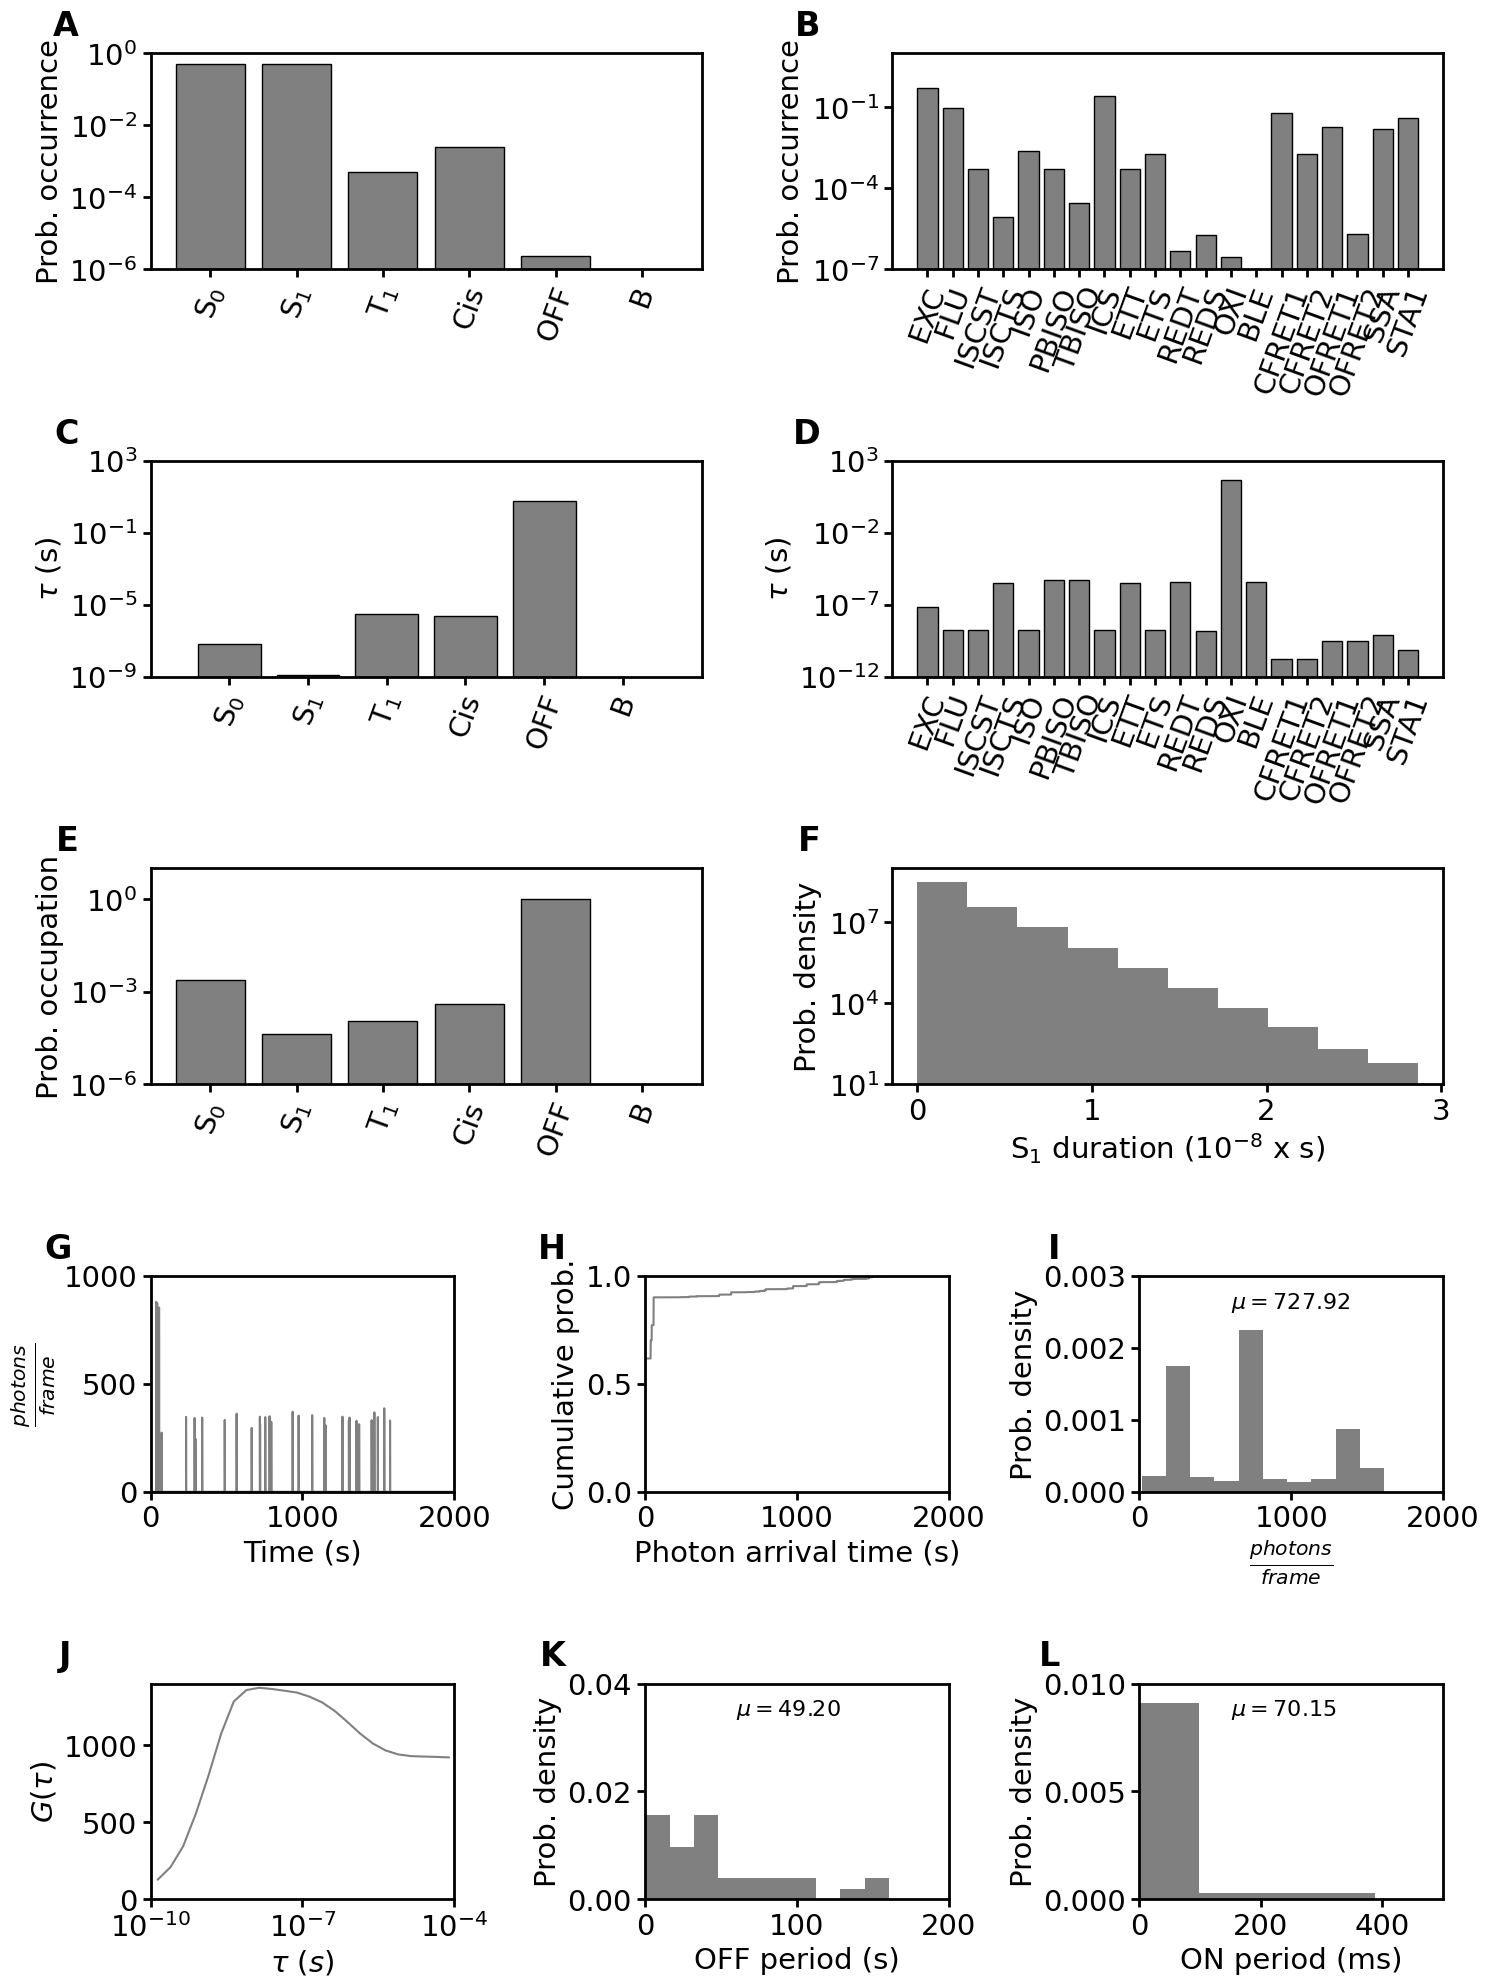

In [9]:
rcParams['axes.linewidth'] = 2
gs = plt.GridSpec(5, 6)
fig = plt.figure(figsize=(15, 20))
color = 'grey'
analysis_plot_param = dict(legend=False, color=color)
ax = fig.add_subplot(gs[0, 0:3])
analysis.plot_frequency_states(ylim=[1e-6, 1e0], axes=ax, **analysis_plot_param)
ax = fig.add_subplot(gs[0, 3:])
analysis.plot_frequency_transitions(ylim=[1e-7, 1e1], axes=ax, diff_dist=False,
                                    **analysis_plot_param)
ax = fig.add_subplot(gs[1, 0:3])
analysis.plot_mean_lifetimes(ylim=[1e-9, 1e3], axes=ax, **analysis_plot_param)
ax = fig.add_subplot(gs[1, 3:])
analysis.plot_mean_transition_times(ylim=[1e-12, 1e3], axes=ax, diff_dist=False,
                                    **analysis_plot_param)
ax = fig.add_subplot(gs[2, 0:3])
analysis.plot_state_occupations(ylim=[1e-6, 1e1], axes=ax, **analysis_plot_param)
ax = fig.add_subplot(gs[2, 3:])
analysis.plot_lifetime_distributions(state_identity=1, axes=ax,
                                    fluorophore='cy5_dna', **analysis_plot_param,
                                    title=None, ylim=[1e1, 1e9], tick_style_x='sci')


ax = fig.add_subplot(gs[3, 0:2])
emis.plot_time_series(axes=ax, color=color, xlim=[0, 2000], ylim=[0, 1000])
ax = fig.add_subplot(gs[3, 2:4])
emis.plot_cumulative_events(axes=ax, color=color, xlim=[0, 2000])
ax = fig.add_subplot(gs[3, 4:])
emis.plot_histogram(axes=ax, color=color, ylim=[0, 0.003], xlim=[0, 2000], display_mean=True)

fcs = fcs_p.FCS(emis)
fcs.autocorrelate_time_points(
    exp_min=-10, exp_max=-4, points_per_base=4, base=10, normalize=True
)
ax = fig.add_subplot(gs[4, 0:2])
fcs.plot(axes=ax, unit="s", color=color, title=None, xlim=[1e-10, 1e-4], ylim=[0, 1400])
blink = bl.Blinking(emis)
ax = fig.add_subplot(gs[4, 2:4])
blink.plot(mode='off_histogram', axes=ax, as_time='s', color=color, xlim=[0, 200], ylim=[0, 0.04])
ax = fig.add_subplot(gs[4, 4:])
blink.plot(mode='on_histogram', axes=ax, as_time='ms', color=color, xlim=[0, 500], ylim=[0, 0.01])
axes = fig.get_axes()
for i, (axis, letter) in enumerate(zip(axes, ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L'])):
    offset = -0.13
    if i > 5:
        offset = -0.26
    axis.text(offset, 1.05, letter, transform=axis.transAxes, fontsize=24, fontweight='bold', va='bottom', ha='right')
fig.tight_layout()

fig.savefig("4f_et_stats.png", bbox_inches='tight', pad_inches=0.1, dpi=300)